In [1]:
from pathlib import Path
import copy
import json
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display, Markdown

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

OUTPUT_DIR = Path(
    "/home/matcho/projects/streaming-flow-policy"
    "/experiments/branch_count/results_adjacent40_200epochs_v1"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "branch_counts": [2, 3, 4],
    "seeds": [0, 1, 2, 3, 4],
    "adjacent_angle_deg": 40.0,
    "branch_time": 0.25,
    "total_time": 1.0,
    "stem_length": 0.25,
    "branch_length": 0.50,
    "sigma_0": 0.05,
    "stabilizing_gain": 2.5,
    "num_train_samples": 100_000,
    "num_validation_samples": 20_000,
    "num_epochs": 200,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "weight_decay": 1e-6,
    "num_test_samples": 1000,
    "test_seed": 0,
    "ode_steps": 1000,
    "success_threshold": 0.05,
    "hidden_dim": 128,
    "num_hidden_layers": 4,
}

config_path = OUTPUT_DIR / "config.json"

if config_path.exists():
    if json.loads(config_path.read_text()) != CONFIG:
        raise ValueError(
            "This directory contains a different configuration. "
            "Use a new output directory."
        )
else:
    config_path.write_text(
        json.dumps(CONFIG, indent=2),
        encoding="utf-8",
    )

# Shared initial samples for every branch count, seed and method.
test_initial = np.random.default_rng(CONFIG["test_seed"]).normal(
    0.0,
    CONFIG["sigma_0"],
    size=(CONFIG["num_test_samples"], 2),
)

print("Device:", DEVICE)
print("Output directory:", OUTPUT_DIR)
print("Models to train: 3 branch counts × 5 seeds = 15")

Device: cuda
Output directory: /home/matcho/projects/streaming-flow-policy/experiments/branch_count/results_adjacent40_200epochs_v1
Models to train: 3 branch counts × 5 seeds = 15


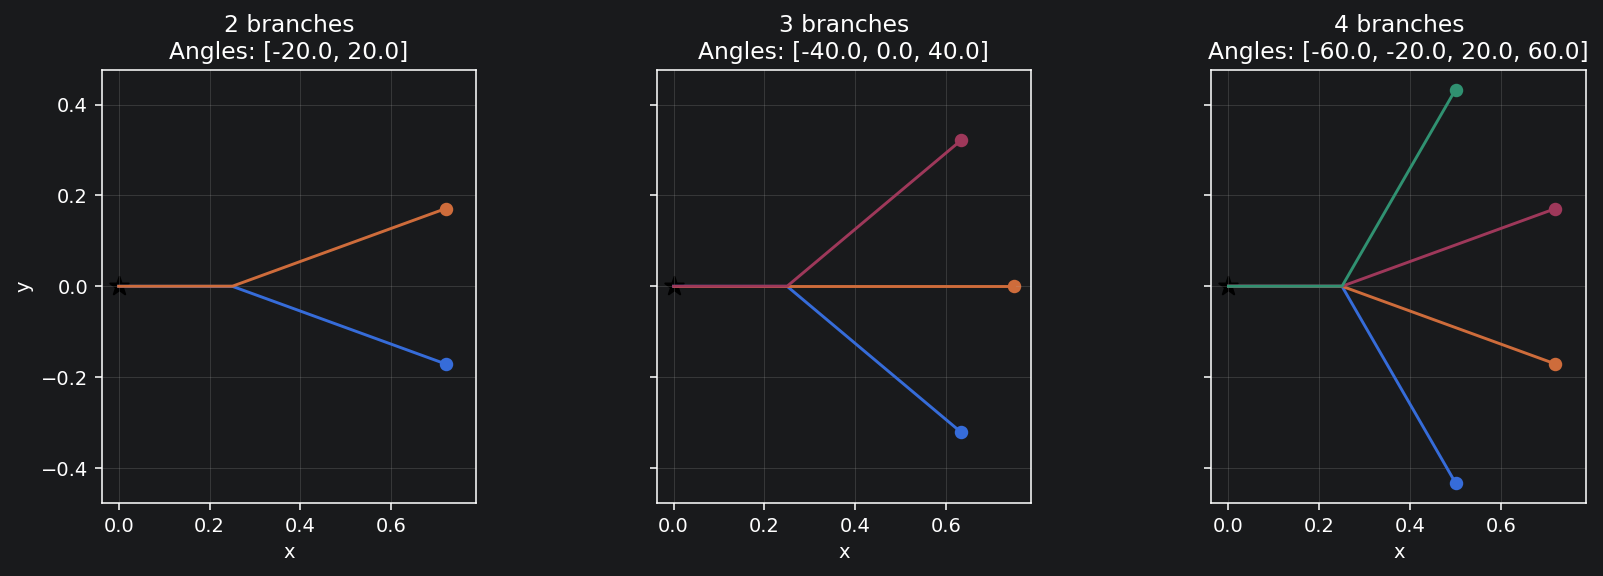

In [2]:
def branch_angles(num_branches):
    return (
        np.arange(num_branches) - (num_branches - 1) / 2
    ) * CONFIG["adjacent_angle_deg"]


def branch_directions(num_branches):
    radians = np.deg2rad(branch_angles(num_branches))
    return np.column_stack([
        np.cos(radians),
        np.sin(radians),
    ])


def smooth_progress(u):
    position = 10*u**3 - 15*u**4 + 6*u**5
    derivative = 30*u**2 - 60*u**3 + 30*u**4
    return position, derivative


def expert_trajectory(times, num_branches, modes):
    """
    times: shape (N,)
    modes: scalar branch index or shape (N,)
    Returns positions and derivatives, both shape (N, 2).
    """
    times = np.asarray(times, dtype=np.float64).reshape(-1)
    modes = np.broadcast_to(
        np.asarray(modes, dtype=np.int64),
        times.shape,
    )

    positions = np.zeros((len(times), 2))
    derivatives = np.zeros_like(positions)

    stem_mask = times <= CONFIG["branch_time"]

    u = times[stem_mask] / CONFIG["branch_time"]
    s, ds = smooth_progress(u)

    positions[stem_mask, 0] = CONFIG["stem_length"] * s
    derivatives[stem_mask, 0] = (
        CONFIG["stem_length"] / CONFIG["branch_time"] * ds
    )

    branch_mask = ~stem_mask
    duration = CONFIG["total_time"] - CONFIG["branch_time"]

    u = (
        times[branch_mask] - CONFIG["branch_time"]
    ) / duration
    s, ds = smooth_progress(u)

    directions = branch_directions(num_branches)[
        modes[branch_mask]
    ]

    positions[branch_mask] = (
        np.array([CONFIG["stem_length"], 0.0])
        + CONFIG["branch_length"] * s[:, None] * directions
    )
    derivatives[branch_mask] = (
        CONFIG["branch_length"] / duration
        * ds[:, None] * directions
    )

    return positions, derivatives


def generate_training_data(num_branches, num_samples, seed):
    rng = np.random.default_rng(seed)

    times = rng.uniform(
        0.0, CONFIG["total_time"], size=num_samples
    )
    modes = rng.integers(
        0, num_branches, size=num_samples
    )

    positions, derivatives = expert_trajectory(
        times, num_branches, modes
    )

    sigma = CONFIG["sigma_0"] * np.exp(
        -CONFIG["stabilizing_gain"] * times
    )
    offsets = sigma[:, None] * rng.standard_normal(
        (num_samples, 2)
    )

    actions = positions + offsets
    targets = (
        derivatives - CONFIG["stabilizing_gain"] * offsets
    )

    inputs = np.column_stack([actions, times])

    return inputs.astype(np.float32), targets.astype(np.float32)


# Display the actual task geometry.
fig, axes = plt.subplots(
    1, 3, figsize=(12, 4), dpi=140,
    sharex=True, sharey=True,
    constrained_layout=True,
)

times = np.linspace(0.0, 1.0, 500)

for ax, count in zip(axes, CONFIG["branch_counts"]):
    for mode in range(count):
        positions, _ = expert_trajectory(times, count, mode)
        ax.plot(positions[:, 0], positions[:, 1])
        ax.scatter(*positions[-1], s=35)

    ax.scatter(0, 0, marker="*", s=100, color="black")
    ax.set_title(
        f"{count} branches\n"
        f"Angles: {branch_angles(count).tolist()}"
    )
    ax.set_xlabel("x")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("y")
plt.show()

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class VelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.register_buffer(
            "input_center",
            torch.tensor([0.375, 0.0, 0.5], dtype=torch.float32),
        )
        self.register_buffer(
            "input_scale",
            torch.tensor([0.5, 0.5, 0.5], dtype=torch.float32),
        )

        layers = []
        width = 3

        for _ in range(CONFIG["num_hidden_layers"]):
            layers.extend([
                nn.Linear(width, CONFIG["hidden_dim"]),
                nn.SiLU(),
            ])
            width = CONFIG["hidden_dim"]

        layers.append(nn.Linear(width, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(
            (inputs - self.input_center) / self.input_scale
        )


def train_model(num_branches, seed):
    set_seed(seed)

    x_train, y_train = generate_training_data(
        num_branches,
        CONFIG["num_train_samples"],
        seed,
    )
    x_val, y_val = generate_training_data(
        num_branches,
        CONFIG["num_validation_samples"],
        seed + 10_000,
    )

    dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(x_train),
        torch.from_numpy(y_train),
    )

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
        num_workers=0,
    )

    val_inputs = torch.from_numpy(x_val).to(DEVICE)
    val_targets = torch.from_numpy(y_val).to(DEVICE)

    model = VelocityMLP().to(
        device=DEVICE, dtype=torch.float32
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["num_epochs"],
    )

    history = {
        "train_loss": [],
        "validation_loss": [],
    }
    best_loss = float("inf")
    best_state = None
    best_epoch = None

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        model.train()
        train_sum = 0.0

        for inputs, targets in loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            loss = nn.functional.mse_loss(model(inputs), targets)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite training loss.")

            loss.backward()
            optimizer.step()
            train_sum += loss.item() * len(inputs)

        model.eval()
        val_sum = 0.0

        with torch.no_grad():
            for offset in range(0, len(val_inputs), 4096):
                inputs = val_inputs[offset:offset + 4096]
                targets = val_targets[offset:offset + 4096]

                loss = nn.functional.mse_loss(model(inputs), targets)

                if not torch.isfinite(loss):
                    raise RuntimeError("Non-finite validation loss.")

                val_sum += loss.item() * len(inputs)

        train_loss = train_sum / len(dataset)
        val_loss = val_sum / len(val_inputs)

        history["train_loss"].append(train_loss)
        history["validation_loss"].append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }

        scheduler.step()

        if epoch == 1 or epoch % 25 == 0:
            print(
                f"Branches={num_branches}, seed={seed} | "
                f"epoch={epoch}/{CONFIG['num_epochs']} | "
                f"train={train_loss:.6f} | val={val_loss:.6f}"
            )

    model.load_state_dict(best_state)
    model.eval()

    history["best_epoch"] = best_epoch
    history["best_validation_loss"] = best_loss

    return model, history

In [4]:
def make_learned_velocity(model):
    evaluation_model = copy.deepcopy(model).to(
        device=DEVICE, dtype=torch.float64
    )
    evaluation_model.eval()

    def velocity(actions, time):
        times = torch.full(
            (len(actions), 1),
            time,
            dtype=actions.dtype,
            device=actions.device,
        )
        return evaluation_model(torch.cat([actions, times], dim=1))

    return velocity


def make_analytic_velocity(num_branches):
    """Equal-prior marginal field with posterior mixture weights."""
    def velocity(actions, time):
        positions, derivatives = expert_trajectory(
            np.full(num_branches, time),
            num_branches,
            np.arange(num_branches),
        )

        positions = torch.as_tensor(
            positions, dtype=actions.dtype, device=actions.device
        )
        derivatives = torch.as_tensor(
            derivatives, dtype=actions.dtype, device=actions.device
        )

        offsets = actions[:, None, :] - positions[None, :, :]
        sigma = CONFIG["sigma_0"] * np.exp(
            -CONFIG["stabilizing_gain"] * time
        )

        logits = -offsets.square().sum(dim=-1) / (2 * sigma**2)
        weights = torch.softmax(logits, dim=1)

        conditional_velocities = (
            derivatives[None, :, :]
            - CONFIG["stabilizing_gain"] * offsets
        )

        return (
            weights[:, :, None] * conditional_velocities
        ).sum(dim=1)

    return velocity


@torch.no_grad()
def integrate_velocity(velocity, num_saved_paths=100):
    actions = torch.as_tensor(
        test_initial, dtype=torch.float64, device=DEVICE
    ).clone()

    dt = CONFIG["total_time"] / CONFIG["ode_steps"]
    paths = [actions[:num_saved_paths].cpu().numpy().copy()]

    for step in range(CONFIG["ode_steps"]):
        time = step * dt

        k1 = velocity(actions, time)
        k2 = velocity(actions + dt*k1/2, time + dt/2)
        k3 = velocity(actions + dt*k2/2, time + dt/2)
        k4 = velocity(
            actions + dt*k3,
            min(time + dt, CONFIG["total_time"]),
        )

        actions = actions + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

        if not torch.isfinite(actions).all():
            raise RuntimeError("Non-finite rollout.")

        paths.append(
            actions[:num_saved_paths].cpu().numpy().copy()
        )

    return (
        actions.cpu().numpy(),
        np.stack(paths, axis=1),
    )


def endpoint_metrics(final_actions, num_branches):
    targets, _ = expert_trajectory(
        np.ones(num_branches),
        num_branches,
        np.arange(num_branches),
    )

    distances = np.linalg.norm(
        final_actions[:, None, :] - targets[None, :, :],
        axis=-1,
    )

    nearest = distances.argmin(axis=1)
    errors = distances.min(axis=1)
    success = errors <= CONFIG["success_threshold"]

    successful_counts = np.bincount(
        nearest[success], minlength=num_branches
    )

    if successful_counts.sum() > 0:
        successful_fractions = (
            successful_counts / successful_counts.sum()
        )
        # Total variation from equal branch proportions,
        # conditioned on endpoint success.
        branch_tv = 0.5 * np.abs(
            successful_fractions - 1.0 / num_branches
        ).sum()
    else:
        successful_fractions = np.zeros(num_branches)
        branch_tv = None

    return {
        "success_005": float(success.mean()),
        "success_001": float(np.mean(errors <= 0.01)),
        "mean_error": float(errors.mean()),
        "p95_error": float(np.quantile(errors, 0.95)),
        "successful_counts_by_branch": successful_counts.tolist(),
        "successful_fractions_by_branch": successful_fractions.tolist(),
        "covered_branches": int(np.sum(successful_counts > 0)),
        "branch_tv_among_successes": (
            None if branch_tv is None else float(branch_tv)
        ),
    }

| Branches | Analytic success | Learned success | Mean endpoint error | Successful-branch TV |
|---:|---:|---:|---:|---:|
| 2 | 100.0% | 100.0% | 0.005292 | 0.0240 |
| 3 | 100.0% | 100.0% | 0.005586 | 0.0257 |
| 4 | 100.0% | 99.7% | 0.006514 | 0.0253 |


2 branches
Analytic successful counts: [518, 482]
seed=0: success=100.0%, counts=[524, 476], best epoch=196

3 branches
Analytic successful counts: [337, 340, 323]
seed=0: success=100.0%, counts=[359, 319, 322], best epoch=198

4 branches
Analytic successful counts: [247, 271, 242, 240]
seed=0: success=99.7%, counts=[256, 267, 250, 224], best epoch=189


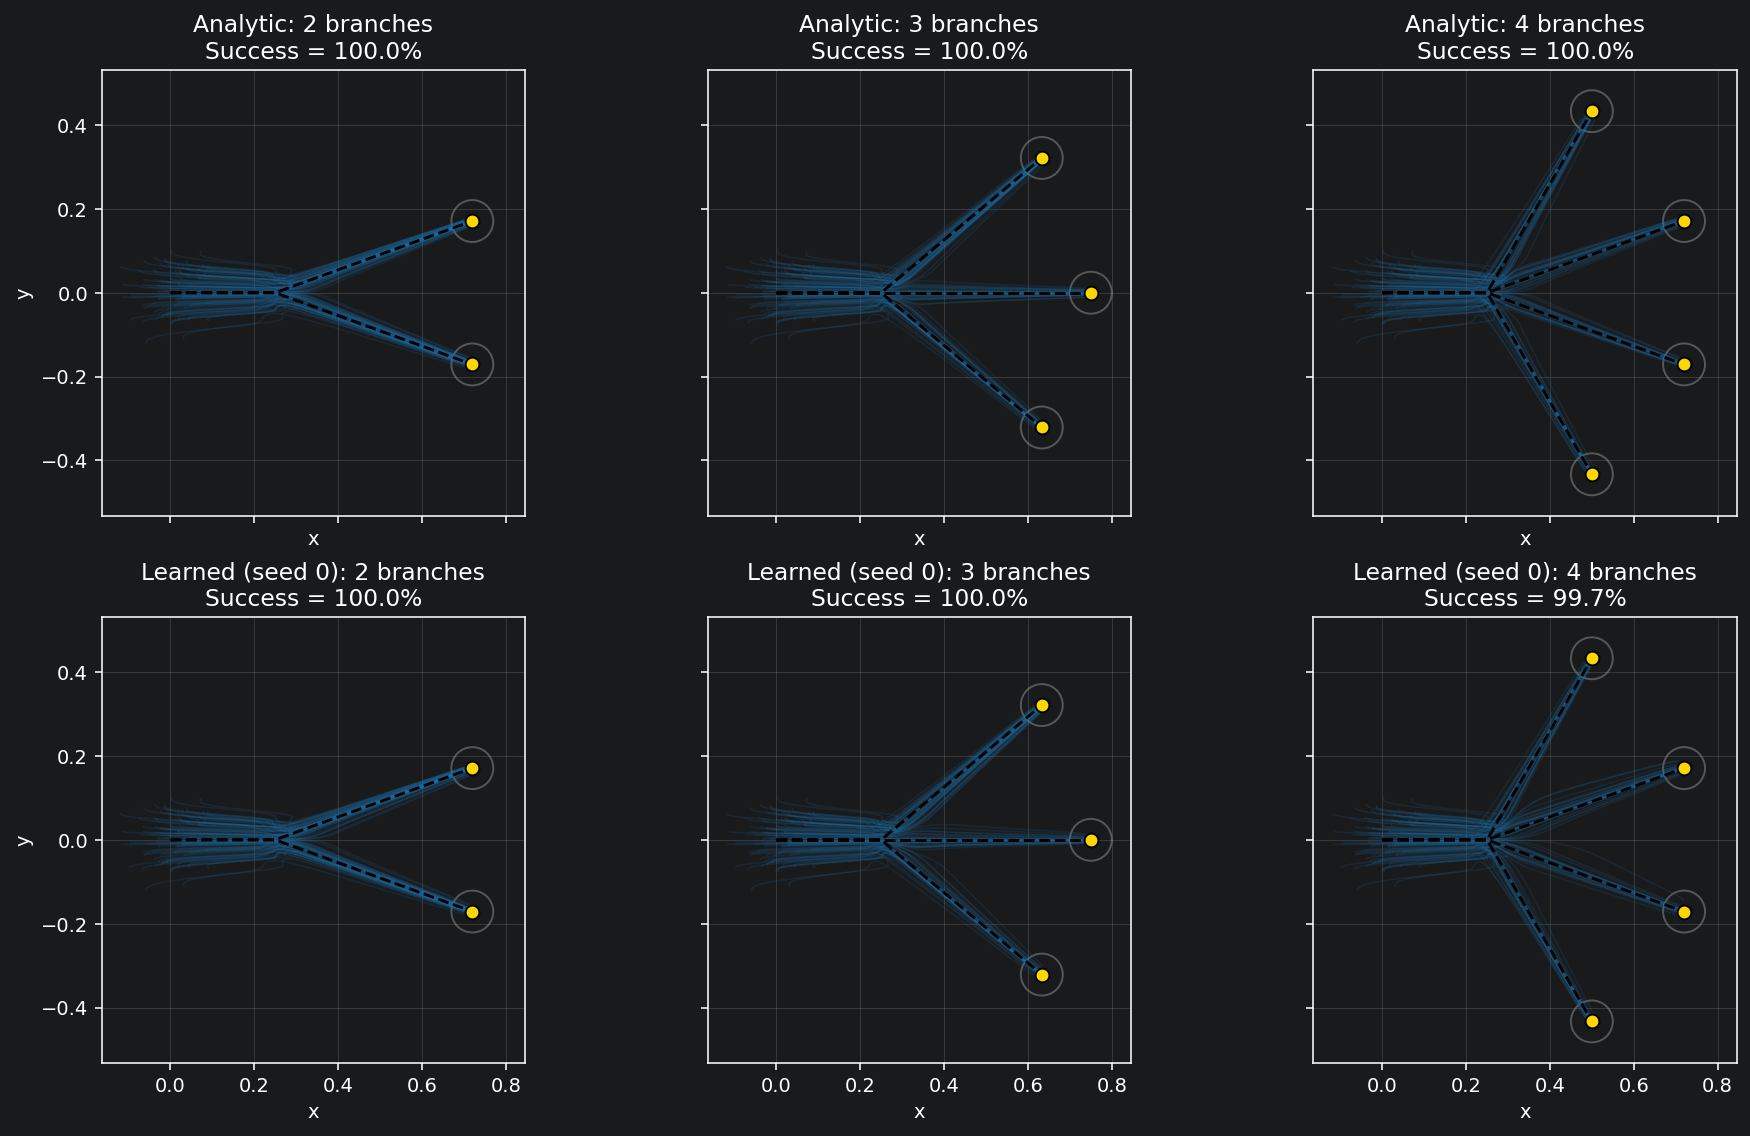

In [6]:
seed = 0

table = [
    "| Branches | Analytic success | Learned success | "
    "Mean endpoint error | Successful-branch TV |",
    "|---:|---:|---:|---:|---:|",
]

for count in CONFIG["branch_counts"]:
    metrics = learned_results[(count, seed)]["metrics"]

    tv = metrics["branch_tv_among_successes"]
    tv_text = f"{tv:.4f}" if tv is not None else "N/A"

    table.append(
        f"| {count} | "
        f"{analytic_results[count]['success_005']:.1%} | "
        f"{metrics['success_005']:.1%} | "
        f"{metrics['mean_error']:.6f} | "
        f"{tv_text} |"
    )

display(Markdown("\n".join(table)))


for count in CONFIG["branch_counts"]:
    result = learned_results[(count, seed)]
    metrics = result["metrics"]

    print(f"\n{count} branches")
    print(
        "Analytic successful counts:",
        analytic_results[count]["successful_counts_by_branch"],
    )

    print(
        f"seed={seed}: "
        f"success={metrics['success_005']:.1%}, "
        f"counts={metrics['successful_counts_by_branch']}, "
        f"best epoch={result['history']['best_epoch']}"
    )


fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 8),
    dpi=140,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

expert_times = np.linspace(0.0, 1.0, 500)

for column, count in enumerate(CONFIG["branch_counts"]):
    for row, method in enumerate(["Analytic", "Learned"]):
        ax = axes[row, column]

        if method == "Analytic":
            filename = f"analytic_branches_{count}.npz"
            metrics = analytic_results[count]
        else:
            filename = f"learned_branches_{count}_seed_{seed}.npz"
            metrics = learned_results[(count, seed)]["metrics"]

        with np.load(
            OUTPUT_DIR / filename,
            allow_pickle=False,
        ) as saved:
            paths = saved["paths"]

        for path in paths:
            ax.plot(
                path[:, 0],
                path[:, 1],
                color="tab:blue",
                alpha=0.15,
                linewidth=0.8,
            )

        for mode in range(count):
            expert, _ = expert_trajectory(
                expert_times,
                count,
                mode,
            )

            ax.plot(
                expert[:, 0],
                expert[:, 1],
                "--",
                color="black",
                linewidth=1.5,
            )

            ax.scatter(
                *expert[-1],
                color="gold",
                edgecolor="black",
                s=50,
                zorder=5,
            )

            ax.add_patch(
                plt.Circle(
                    expert[-1],
                    CONFIG["success_threshold"],
                    fill=False,
                    color="gray",
                    alpha=0.6,
                )
            )

        seed_label = f" (seed {seed})" if method == "Learned" else ""

        ax.set_title(
            f"{method}{seed_label}: {count} branches\n"
            f"Success = {metrics['success_005']:.1%}"
        )

        ax.set_xlabel("x")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

axes[0, 0].set_ylabel("y")
axes[1, 0].set_ylabel("y")

fig.savefig(
    OUTPUT_DIR / f"branch_count_trajectories_seed_{seed}.png",
    dpi=180,
)

plt.show()